## תרגול מסכם

בלי להריץ, תארו במילים מה מחשב הקוד הבא, ומה יהיה ה-`shape` של `spread`:

In [1]:
import numpy as np

g = 9.8
theta = np.radians(45)
v0_runs = np.array([18.0, 19.5, 20.0, 20.5, 22.0])
t = np.linspace(0, 3, 40)

Y = v0_runs[:, None] * np.sin(theta) * t - 0.5 * g * t**2
spread = Y.std(axis=0)

`````{admonition} פתרון
:class: dropdown, tip
`Y` נבנה בעזרת broadcasting: `v0_runs[:, None]` בצורה `(5, 1)` מול `t` בצורה `(40,)`, נותן `Y` בצורה `(5, 40)` — 5 ריצות, 40 נקודות זמן. `Y.std(axis=0)` מצמצם את ציר הריצות (`axis=0` נעלם), ומחזיר את **סטיית התקן של הגובה על פני הריצות, בכל נקודת זמן בנפרד**.

`spread.shape` הוא `(40,)` — ערך אחד לכל זמן, בדיוק כמו התבנית שראינו בסעיף 9.7.
`````

---

הקוד הבא נועד לחשב מהירות אנכית מקורבת מתוך מדגם גובה `y`, ולצייר אותה מול הזמן. יש בו באג — אתרו ותקנו:

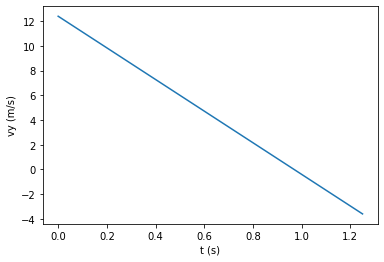

In [2]:
y = np.array([0.0, 3.1, 5.4, 6.9, 7.6, 7.5, 6.6])
t_meas = np.linspace(0, 1.5, 7)

vy_approx = np.diff(y) / np.diff(t_meas)

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(t_meas[:-1], vy_approx)   # <- שימו לב כאן
ax.set_xlabel("t (s)")
ax.set_ylabel("vy (m/s)")
plt.show()

`````{admonition} פתרון
:class: dropdown, tip
הקוד רץ בלי שגיאה — וזו בדיוק הבעיה. `np.diff` מקצר את המערך מ-7 איברים ל-6, ו-`t_meas[:-1]` "מתאים" בגודלו (גם 6), אבל **לא** במשמעות הפיזיקלית: `t_meas[:-1]` הן נקודות ה**התחלה** של כל קטע, בעוד ש-`vy_approx[i]` מייצג את המהירות **על פני** הקטע — הערך הנכון הוא **אמצע** הקטע, לא תחילתו. הגרף "עובד" ונראה סביר, אבל כל הנקודות שלו מוזזות בחצי צעד שמאלה. זה בדיוק הבאג שראינו בסעיף 9.8.

```python
t_mid = (t_meas[:-1] + t_meas[1:]) / 2   # נקודת האמצע של כל קטע, לא ההתחלה
fig, ax = plt.subplots()
ax.plot(t_mid, vy_approx)
ax.set_xlabel("t (s)")
ax.set_ylabel("vy (m/s)")
plt.show()
```
`````

---

כתבו פונקציה `max_height_per_run(Y)` שמקבלת מערך גבהים `Y` בצורה `(n_runs, n_t)` (ריצה, זמן) ומחזירה מערך `(n_runs,)` עם הגובה המרבי של כל ריצה.

In [3]:
def max_height_per_run(Y):
    # כתבו כאן
    pass

# בדיקה:
# max_height_per_run(np.array([[0, 2, 3, 1], [0, 1, 4, 2]]))

`````{admonition} פתרון
:class: dropdown, tip
```python
def max_height_per_run(Y):
    return Y.max(axis=1)   # axis=1 (זמן) נעלם, ציר הריצות נשאר

print(max_height_per_run(np.array([[0, 2, 3, 1], [0, 1, 4, 2]])))
```
`````